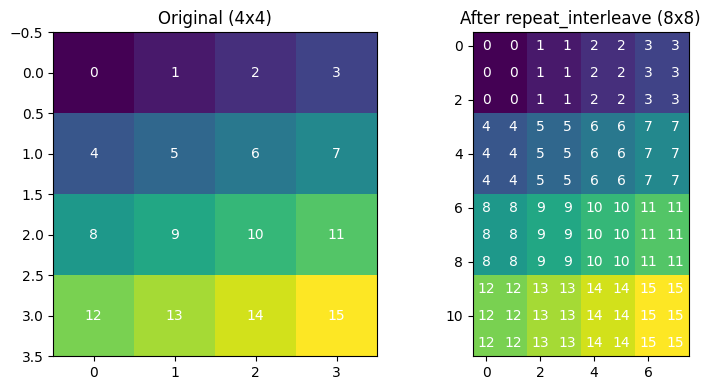

In [3]:
import torch
import matplotlib.pyplot as plt

# 构造一个简单的 1,a,a,n tensor，这里 n=1，方便可视化
a = 4
x = torch.arange(a * a).reshape(1, a, a, 1)  # (1,4,4,1)

# repeat_interleave 在第1、2维扩展
y = x.repeat_interleave(3, dim=1).repeat_interleave(2, dim=2)  # (1,8,8,1)

# 可视化前后
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# 原始 tensor
axes[0].imshow(x[0, :, :, 0].numpy(), cmap="viridis")
axes[0].set_title("Original (4x4)")
for i in range(a):
    for j in range(a):
        axes[0].text(j, i, f"{x[0,i,j,0].item()}", ha="center", va="center", color="w")

# 扩展后的 tensor
axes[1].imshow(y[0, :, :, 0].numpy(), cmap="viridis")
axes[1].set_title("After repeat_interleave (8x8)")
for i in range(y.shape[1]):
    for j in range(y.shape[2]):
        axes[1].text(j, i, f"{y[0,i,j,0].item()}", ha="center", va="center", color="w")

plt.tight_layout()
plt.show()


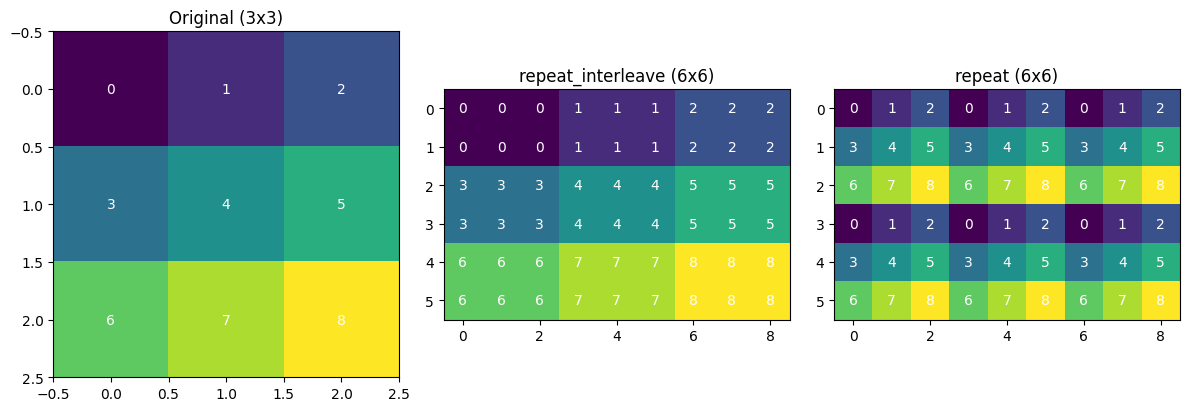

In [5]:
import torch
import matplotlib.pyplot as plt

# 构造一个简单的 (1,a,a,1) tensor，方便看
a = 3
x = torch.arange(a * a).reshape(1, a, a, 1)  # (1,3,3,1)

m = 2  # 放大/平铺倍数
n = 3
# 方法1: repeat_interleave (逐元素复制，相当于像素放大)
y_interleave = x.repeat_interleave(m, dim=1).repeat_interleave(n, dim=2)  # (1,6,6,1)

# 方法2: repeat (整体平铺，相当于tile)
y_repeat = x.repeat(1, m, n, 1)  # (1,6,6,1)

# 可视化函数
def show_tensor(tensor, title, ax):
    arr = tensor[0, :, :, 0].numpy()
    ax.imshow(arr, cmap="viridis")
    ax.set_title(title)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, f"{arr[i,j]}", ha="center", va="center", color="w")

# 绘图
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
show_tensor(x, "Original (3x3)", axes[0])
show_tensor(y_interleave, "repeat_interleave (6x6)", axes[1])
show_tensor(y_repeat, "repeat (6x6)", axes[2])
plt.tight_layout()
plt.show()


### datasets

## mask 转为patch的权重比例

In [11]:
import torch
import torch.nn.functional as F

def mask_to_patch_ratio(mask, patch_size=16):
    """
    Args:
        mask: (B, 1, H, W)  0/1 mask
        patch_size: int, patch 大小 (e.g. 16)
    Returns:
        patch_ratio: (B, H/patch, W/patch) 每个 patch 内 1 的比例
    """
    B, C, H, W = mask.shape
    # 用 avg_pool 把每个 patch 平均化
    pooled = F.avg_pool2d(mask.float(), kernel_size=patch_size, stride=patch_size)
    return pooled.flatten(2).transpose(1, 2)  # (B, H/patch, W/patch)



In [12]:
mask = torch.randint(0, 2, (1, 1, 32, 32))  # (B=1, 1, H=64, W=64)
patch_ratio = mask_to_patch_ratio(mask, patch_size=16)
 # torch.Size([1, 4, 4])
print(patch_ratio)
print(mask[0,0,:16,:].sum())
mask[0,0,:16,:16].shape

tensor([[[0.5156],
         [0.4805],
         [0.5625],
         [0.4844]]])
tensor(255)


torch.Size([16, 16])

In [10]:
124/(16*16)

0.484375

In [14]:
from omegaconf import OmegaConf
setting_config = OmegaConf.load('configs/debug.yaml')

In [15]:
setting_config

{'net': {'de': 5, 'en': 6}, 'dd': {'be': 5}}